In [5]:
# ===============================
# Bubble Sort
# ===============================

def bubble_sort(arr):
    arr = arr.copy()
    n = len(arr)

    for i in range(n):
        swapped = False

        for j in range(0, n - i - 1):

            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True

        if not swapped:
            break

    return arr


# ===============================
# Merge Sort
# ===============================

def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


def merge(left, right):

    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [6]:
import random

def random_array(n):
    return [random.randint(0,1000) for _ in range(n)]

def sorted_array(n):
    return list(range(n))

def reversed_array(n):
    return list(range(n,0,-1))

def almost_sorted_array(n):

    arr = list(range(n))

    for _ in range(int(n * 0.05)):
        i = random.randint(0,n-1)
        j = random.randint(0,n-1)

        arr[i], arr[j] = arr[j], arr[i]

    return arr

In [7]:
import time
import numpy as np

sizes = [1000, 5000, 10000, 50000]

tests = {
    "Random": random_array,
    "Sorted": sorted_array,
    "Reversed": reversed_array,
    "Almost Sorted": almost_sorted_array
}

results = {}

for test_name, generator in tests.items():

    bubble_times = []
    merge_times = []

    for size in sizes:

        bubble_runs = []
        merge_runs = []

        for _ in range(5):

            arr = generator(size)

            # Bubble Sort только до 10000
            if size <= 10000:
                start = time.time()
                bubble_sort(arr)
                bubble_runs.append(time.time() - start)

            start = time.time()
            merge_sort(arr)
            merge_runs.append(time.time() - start)

        if size <= 10000:
            bubble_times.append(np.mean(bubble_runs))
        else:
            bubble_times.append(None)

        merge_times.append(np.mean(merge_runs))

    results[test_name] = (bubble_times, merge_times)

print("Тестирование завершено")

Тестирование завершено


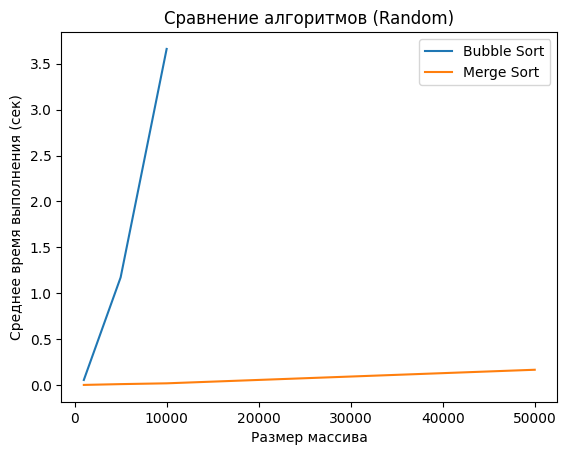

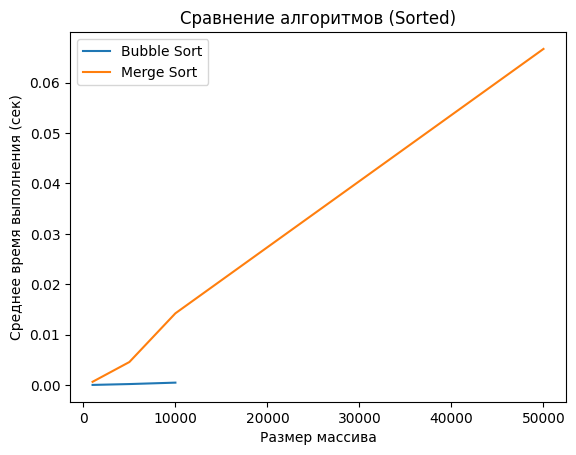

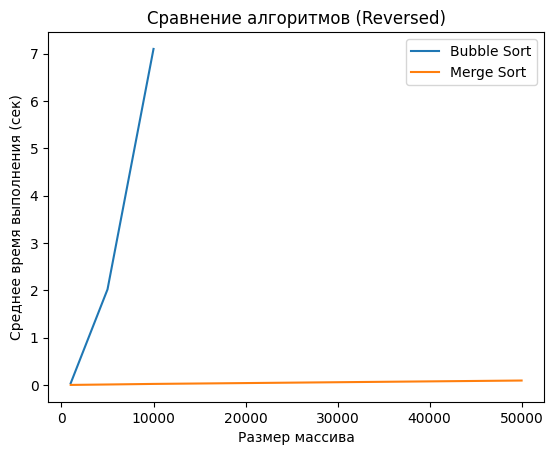

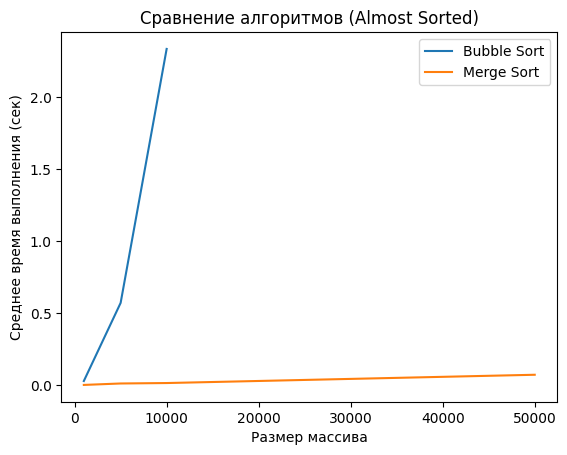

In [9]:
import matplotlib.pyplot as plt

for test_name, (bubble_times, merge_times) in results.items():

    plt.figure()

    plt.plot(sizes, bubble_times, label="Bubble Sort")
    plt.plot(sizes, merge_times, label="Merge Sort")

    plt.xlabel("Размер массива")
    plt.ylabel("Среднее время выполнения (сек)")
    plt.title(f"Сравнение алгоритмов ({test_name})")

    plt.legend()
    plt.show()

In [10]:
import pandas as pd

for test_name, (bubble_times, merge_times) in results.items():

    df = pd.DataFrame({
        "Размер массива": sizes,
        "Bubble Sort (сек)": bubble_times,
        "Merge Sort (сек)": merge_times
    })

    print("\nТип данных:", test_name)
    display(df)


Тип данных: Random


,Размер массива,Bubble Sort (сек),Merge Sort (сек)
0,1000,0.055903,0.002009
1,5000,1.172902,0.010729
2,10000,3.660841,0.019432
3,50000,NaN,0.167188



Тип данных: Sorted


,Размер массива,Bubble Sort (сек),Merge Sort (сек)
0,1000,0.000033,0.000652
1,5000,0.000205,0.004575
2,10000,0.000486,0.014233
3,50000,NaN,0.066666



Тип данных: Reversed


,Размер массива,Bubble Sort (сек),Merge Sort (сек)
0,1000,0.036778,0.000859
1,5000,2.019668,0.009924
2,10000,7.101642,0.022103
3,50000,NaN,0.093634



Тип данных: Almost Sorted


,Размер массива,Bubble Sort (сек),Merge Sort (сек)
0,1000,0.028629,0.001565
1,5000,0.571385,0.011583
2,10000,2.335495,0.014641
3,50000,NaN,0.072145
